In [1]:
import os, tempfile

big_tmp_dir = "C:/joblib_temp"
os.makedirs(big_tmp_dir, exist_ok=True)
os.environ["JOBLIB_TEMP_FOLDER"] = big_tmp_dir


In [2]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    average_precision_score,
    PrecisionRecallDisplay
)

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder, LabelEncoder
from collections import Counter
from sklearn.dummy import DummyClassifier

from collections import defaultdict

In [3]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [4]:
data_dir = Path('../../results')

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [78]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

In [79]:
# Define target variables

y_train_rating = df_train['rating']
y_test_rating = df_test['rating']

y_train_titleType = df_train['titleType']
y_test_titleType = df_test['titleType']

In [80]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

# Pre-Processing

In [81]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


In [82]:
# drop target variables
df_train.drop(columns=['rating', 'averageRating'], inplace=True) 
df_test.drop(columns=['rating', 'averageRating'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber', 'regions',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio',
       'hasAwards', 'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [83]:
num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [84]:
num_cols, bool_cols, cat_cols #NB: cat_cols only contains titleType, this is for rating as a target

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
        'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index(['titleType'], dtype='object'))

In [85]:
# Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

Consistently w/ Logistic Regression, we keep the top 25 countries and regions, aggregating the rest into an 'Other' category.

In [86]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [87]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

top_n_countries = 25
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

In [88]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

top_n_regions = 25
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [89]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        'Return feature names for output features'
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [90]:
def build_preprocessor(num_cols, bool_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols), #TREES: NO SCALING NEEDED
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),  # No need for drop='first': RF handles redundant feats
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

# Rating

In [18]:
pipeline_rating = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [19]:
# DEFAULT PARAMS

default_rating = cross_val_score(pipeline_rating, df_train, y_train_rating, cv=3, scoring='f1_macro')

print(f"Best score: {default_rating.mean():.3f}")
print(f"Default parameter: {pipeline_rating.get_params()}")

Best score: 0.296
Default parameter: {'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num', 'passthrough',
                                 Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
       'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
       'writerCredits', 'numGenres', 'criticReviewsRatio'],
      dtype='object')),
                                ('bool', 'passthrough',
                                 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
       'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
       'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')),
                                ('cat', OneHotEncoder(),
                                 Index(['titleType'], dtype='object')),
                                ('countries', MultiLabelBinarizerTransformer(),
                                 'country_cleaned'),
                                ('genres

In [20]:
# default model on test set

default_rating_model = pipeline_rating.fit(df_train, y_train_rating)
y_pred_rating_default = pipeline_rating.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating_default, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.444     0.182     0.258        22
      (1, 2]      0.378     0.105     0.165       133
      (2, 3]      0.346     0.072     0.119       374
      (3, 4]      0.363     0.105     0.163      1035
      (4, 5]      0.370     0.172     0.235      2750
      (5, 6]      0.375     0.338     0.356      6270
      (6, 7]      0.424     0.492     0.455     11750
      (7, 8]      0.503     0.653     0.568     14613
      (8, 9]      0.459     0.301     0.364      6591
     (9, 10]      0.587     0.238     0.339      1319

    accuracy                          0.454     44857
   macro avg      0.425     0.266     0.302     44857
weighted avg      0.447     0.454     0.437     44857



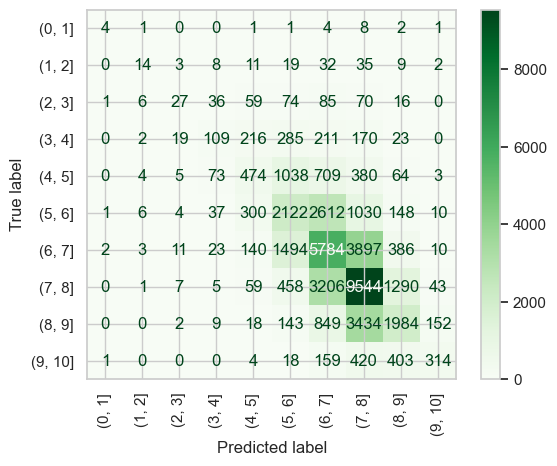

In [21]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_rating_default, y_true=y_test_rating,
                                        xticks_rotation=90,
                                        cmap='Greens')

To get an idea of how the number of estimators can impact the model's performance, we do a cross-validation for 10,100,300,500 estimators while keeping all other params fixed to their default values. 

→ performances stay the same regardless of the number of base models used.

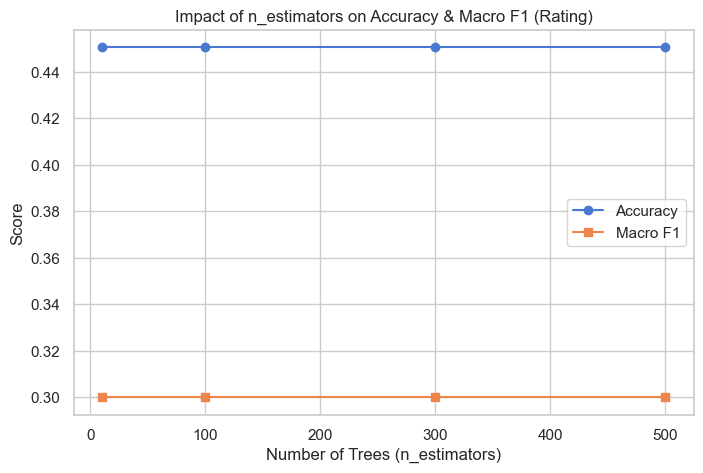

In [22]:
n_estimators_list = [10, 100, 300, 500]
accuracy_scores = []
f1_scores = []

for n in n_estimators_list:
    
    pipeline_n_estimators = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', RandomForestClassifier(random_state=42))
    ])
    # Accuracy
    acc = cross_val_score(pipeline_n_estimators, df_train, y_train_rating, cv=5, scoring='accuracy').mean()
    accuracy_scores.append(acc)
    
    # Macro F1
    f1 = cross_val_score(pipeline_n_estimators, df_train, y_train_rating, cv=5, scoring='f1_macro').mean()
    f1_scores.append(f1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, accuracy_scores, marker='o', label='Accuracy')
plt.plot(n_estimators_list, f1_scores, marker='s', label='Macro F1')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Score')
plt.title('Impact of n_estimators on Accuracy & Macro F1 (Rating)')
plt.legend()
plt.show()


## Hyperparameter Tuning

For each number of estimators, we run a random search with 3fold-cross-validation to determine the best configurations of hyperparameters. Among the three resulting best models, we choose the one with the highest mean macro F1.

In [23]:
#Refinements after experiments: max_depth was often none, min_samples_split and min_samples_leaf were often the smallest numbers.

param_list_100 = {
    'clf__n_estimators': [100],
    'clf__criterion': ["gini", "entropy"], #log_loss is the same as entropy in sklearn's implementation
    'clf__max_depth': [None, 5, 15, 25],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__class_weight': [None, 'balanced']
}

param_list_300 = {
    'clf__n_estimators': [300],
    'clf__criterion': ["gini", "entropy"],
    'clf__max_depth': [None, 5, 15, 25],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__class_weight': [None, 'balanced']
}

param_list_500 = {
    'clf__n_estimators': [500],
    'clf__criterion': ["gini", "entropy"],
    'clf__max_depth': [None, 5, 15, 25],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__class_weight': [None, 'balanced']
}

In [ ]:
random_search_100 = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_100,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_100.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_100 = random_search_100.best_index_
train_macro_f1_100 = random_search_100.cv_results_['mean_train_f1_macro'][best_index_100]

print(f"Validation macro F1: {random_search_100.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_100:.3f}")
print(f"Best parameters: {random_search_100.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation macro F1: 0.308; vs macro F1 on train: 0.964
Best parameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}


In [27]:
cv_results_100 = pd.DataFrame(random_search_100.cv_results_)
cv_results_100['overfitting_gap'] = cv_results_100['mean_train_f1_macro'] - cv_results_100['mean_test_f1_macro']

cv_results_100.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(20)

display(cv_results_100[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.242355,0.171398,0.070956
1,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.157093,0.142809,0.014285
2,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.376642,0.210840,0.165802
3,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.184697,0.145344,0.039354
4,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.880435,0.300204,0.580230
...,...,...,...,...
95,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.236642,0.166305,0.070336
96,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.768119,0.252136,0.515982
97,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.391566,0.184242,0.207324
98,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.633589,0.262761,0.370828


In [28]:
random_search_300 = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_300,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_300.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_300 = random_search_300.best_index_
train_macro_f1_300 = random_search_300.cv_results_['mean_train_f1_macro'][best_index_300]

print(f"Validation macro F1: {random_search_300.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_300:.3f}")
print(f"Best parameters: {random_search_300.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation macro F1: 0.308; vs macro F1 on train: 0.968
Best parameters: {'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}


In [29]:
cv_results_300 = pd.DataFrame(random_search_300.cv_results_)
cv_results_300['overfitting_gap'] = cv_results_300['mean_train_f1_macro'] - cv_results_300['mean_test_f1_macro']

cv_results_300.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(20)

display(cv_results_300[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.243150,0.170756,0.072395
1,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.160435,0.144201,0.016235
2,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.387048,0.214093,0.172955
3,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.185094,0.146022,0.039072
4,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.888778,0.301988,0.586790
...,...,...,...,...
95,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.235483,0.166954,0.068529
96,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.772492,0.253945,0.518547
97,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.392003,0.184830,0.207173
98,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.647753,0.266790,0.380962


In [ ]:
random_search_500 = RandomizedSearchCV(
    pipeline_rating,
    param_distributions=param_list_500,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_500.fit(df_train, y_train_rating)

print(f"BEST MODEL:")
best_index_500 = random_search_500.best_index_
train_macro_f1_500 = random_search_500.cv_results_['mean_train_f1_macro'][best_index_500]

print(f"Validation macro F1: {random_search_500.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_500:.3f}")
print(f"Best parameters: {random_search_500.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation macro F1: 0.308; vs macro F1 on train: 0.968
Best parameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}


In [31]:
cv_results_500 = pd.DataFrame(random_search_500.cv_results_)
cv_results_500['overfitting_gap'] = cv_results_500['mean_train_f1_macro'] - cv_results_500['mean_test_f1_macro']

cv_results_500.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(20)

display(cv_results_500[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.242696,0.170296,0.072399
1,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.159953,0.143390,0.016563
2,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.391422,0.215173,0.176249
3,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.185326,0.146241,0.039084
4,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.889757,0.301593,0.588164
...,...,...,...,...
95,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.233183,0.165036,0.068147
96,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.771817,0.254354,0.517463
97,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.390195,0.184430,0.205766
98,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.651585,0.268196,0.383389


In [32]:
df_results_100 = pd.DataFrame(random_search_100.cv_results_)
df_results_300 = pd.DataFrame(random_search_300.cv_results_)
df_results_500 = pd.DataFrame(random_search_500.cv_results_)

#sort by macrof1
df_results_100= df_results_100.sort_values(by="mean_test_f1_macro", ascending=False)
df_results_300 = df_results_300.sort_values(by="mean_test_f1_macro", ascending=False)
df_results_500 = df_results_500.sort_values(by="mean_test_f1_macro", ascending=False)

In [33]:
for name, df in {
    "100": df_results_100,
    "300": df_results_300,
    "500": df_results_500,
}.items():
    row = df.iloc[0]
    print(
        f"Model {name}: "
        f"macro_f1={row['mean_test_f1_macro']:.6f} ± {row['std_test_f1_macro']:.6f}, "
        f"accuracy={row['mean_test_accuracy']:.6f} ± {row['std_test_accuracy']:.6f}"
    )

Model 100: macro_f1=0.307712 ± 0.004325, accuracy=0.437266 ± 0.001930
Model 300: macro_f1=0.308350 ± 0.002541, accuracy=0.443830 ± 0.002798
Model 500: macro_f1=0.307647 ± 0.001996, accuracy=0.445187 ± 0.002801


They're all overfitted, we choose model 300 for best performance (by very little) and most stable.

NB: for all models, the winning param combination is almost the same (only difference model 300 uses gini).

In [34]:
RF_rating = random_search_300.best_estimator_
#joblib.dump(RF_rating, data_dir/"RF_rating.pkl")

NB: RF_rating.pkl was moved bc of its size. It's available at the following link:
[RF_rating.pkl (2.3 GB)](https://1drv.ms/u/c/e03777c90ec9d443/EXazl7UfrelAqNyF7QRg3JwB5L-qnZoVRd2zn4rgMJx6Lw?e=am21Le)

In [35]:
y_pred_rating = RF_rating.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.333     0.273     0.300        22
      (1, 2]      0.292     0.158     0.205       133
      (2, 3]      0.248     0.086     0.127       374
      (3, 4]      0.285     0.138     0.186      1035
      (4, 5]      0.344     0.230     0.276      2750
      (5, 6]      0.361     0.402     0.380      6270
      (6, 7]      0.441     0.454     0.448     11750
      (7, 8]      0.534     0.595     0.563     14613
      (8, 9]      0.414     0.377     0.395      6591
     (9, 10]      0.447     0.311     0.367      1319

    accuracy                          0.452     44857
   macro avg      0.370     0.302     0.325     44857
weighted avg      0.445     0.452     0.446     44857



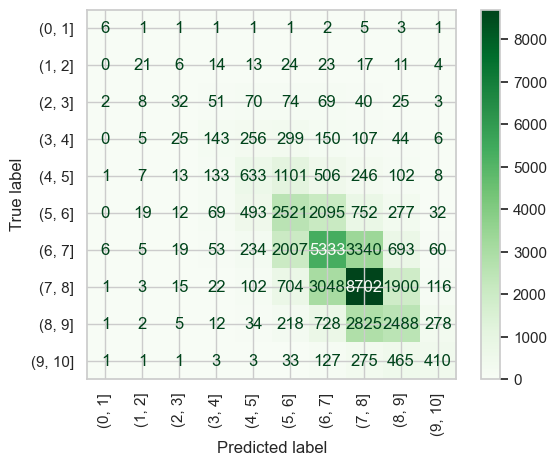

In [36]:
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_rating, y_true=y_test_rating,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Highest performing model so far. Wrt to the others, more balanced performances among classes (6 classes w/ F1 >= 0.300, vs only 4 for SVM w/ RBF).

The middle of the Gaussian is still where the model has the best chance of generalization: best performing is (7,8] (highest support) followed by (6,7] (second highest support). As we move to the sides of the bell, the model gets more and more confused: first among neighboring classes, then, for the minority classes (from 0 to 4) confusion is quite spread out: it's a left-skewed distribution.

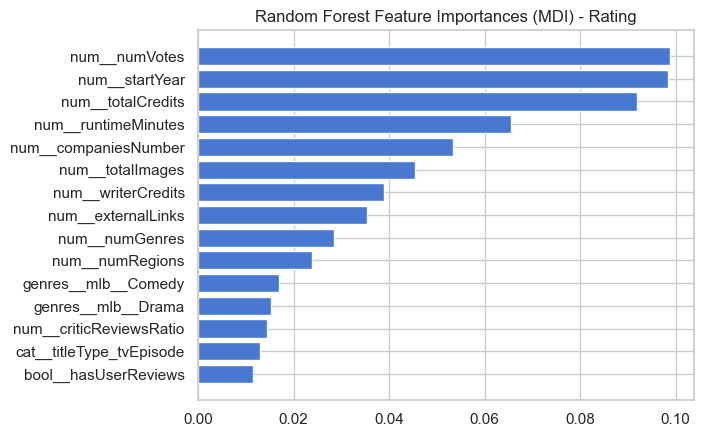

In [37]:
nbr_features = 15

RF_rating_clf = RF_rating.named_steps['clf']
RF_rating_preprocessor = RF_rating.named_steps['preprocessor']
feature_names = RF_rating_preprocessor.get_feature_names_out()
tree_feature_importances = RF_rating_clf.feature_importances_

sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

y_ticks = np.arange(0, len(sorted_idx))
fig, ax = plt.subplots()
plt.barh(y_ticks, tree_feature_importances[sorted_idx])
plt.yticks(y_ticks, feature_names[sorted_idx])
plt.title("Random Forest Feature Importances (MDI) - Rating")
plt.show()

FEATURE IMPORTANCE

startYear: it was the only feat w/ (very mild, 0.20) positive correlation to averageRating.

totalCredits and numVotes: mild correlation (0.47). Their link to rating is unclear: either non-linear relationship or significant interaction between variables.

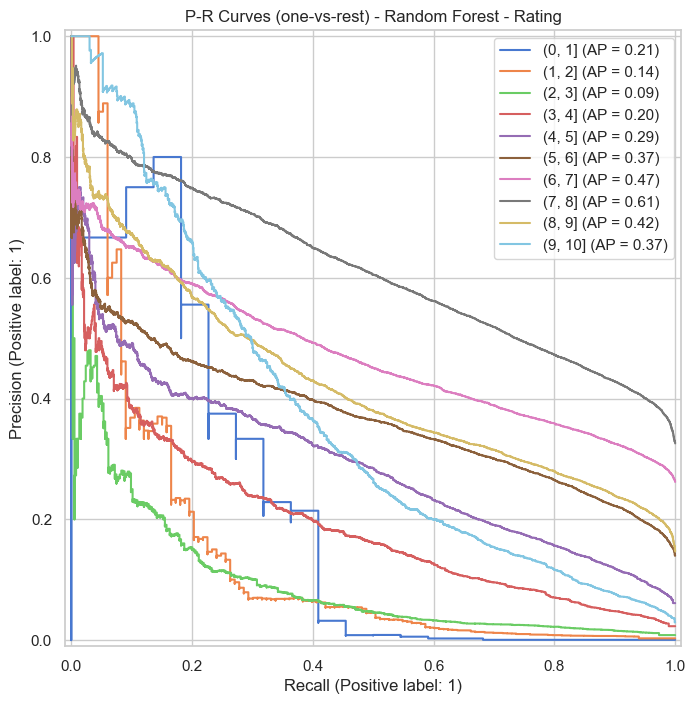

Macro average PR AUC: 0.318


In [38]:
# Get the classes and predictions from your trained model
class_labels = RF_rating.classes_
y_score = RF_rating.predict_proba(df_test)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_rating, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("P-R Curves (one-vs-rest) - Random Forest - Rating")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")

Not very good trade off between precision and recall.

# TitleType

## Pre-processing

In [95]:
# Overwrite
df_train = train.copy()
df_test = test.copy()

In [96]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [97]:
# drop target variable and rating (we'll use averageRating)
df_train.drop(columns=['rating', 'titleType'], inplace=True) 
df_test.drop(columns=['rating', 'titleType'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'canHaveEpisodes', 'numRegions',
       'countryOfOrigin', 'genres', 'companiesNumber', 'averageRating',
       'regions', 'externalLinks', 'writerCredits', 'numGenres',
       'criticReviewsRatio', 'hasAwards', 'hasAwardsOrNominations',
       'hasVideos', 'hasCriticsReviews', 'hasUserReviews',
       'moreDirectorsCredits', 'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [98]:
# overwrite to make sure they're up to date

num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [99]:
num_cols, bool_cols, cat_cols

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'averageRating',
        'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index([], dtype='object'))

In [100]:
# Preprocess Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

## Default params

In [45]:
pipeline_tts = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [46]:
# DEFAULT PARAMS

default_tts = cross_val_score(pipeline_tts, df_train, y_train_titleType, cv=3, scoring='f1_macro')

print(f"Best score: {default_tts.mean():.3f}")
print(f"Default parameter: {pipeline_tts.get_params()}")

Best score: 0.707
Default parameter: {'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num', 'passthrough',
                                 Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
       'totalCredits', 'numRegions', 'companiesNumber', 'averageRating',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio'],
      dtype='object')),
                                ('bool', 'passthrough',
                                 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
       'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
       'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')),
                                ('cat', OneHotEncoder(),
                                 Index([], dtype='object')),
                                ('countries', MultiLabelBinarizerTransformer(),
                                 'country_cleaned'),
                                ('

In [47]:
# default model on test set

default_tts_model = pipeline_tts.fit(df_train, y_train_titleType)
y_pred_tts_default = pipeline_tts.predict(df_test)
print(classification_report(y_test_titleType, y_pred_tts_default, digits=3))

              precision    recall  f1-score   support

       movie      0.884     0.983     0.930     11045
       short      0.934     0.977     0.955      4930
   tvEpisode      0.977     0.996     0.986     21234
tvMiniSeries      0.892     0.489     0.632       491
     tvMovie      0.824     0.395     0.534      1861
    tvSeries      0.917     0.990     0.952      2820
     tvShort      0.875     0.080     0.146        88
   tvSpecial      0.873     0.419     0.566       327
       video      0.863     0.526     0.654      1535
   videoGame      0.973     0.888     0.928       526

    accuracy                          0.936     44857
   macro avg      0.901     0.674     0.728     44857
weighted avg      0.934     0.936     0.928     44857



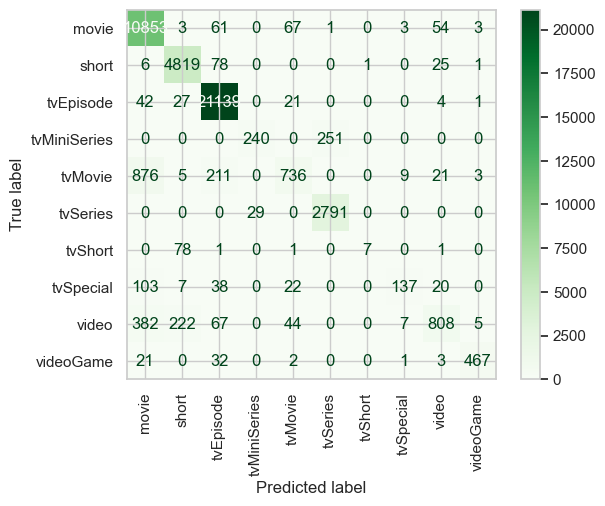

In [48]:
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_tts_default, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')

To get an idea of how the number of estimators can impact the model's performance, let's do a cross-validation for 10,100,300,500 estimators while keeping other params fixed to their default values. 
→ uninfluential


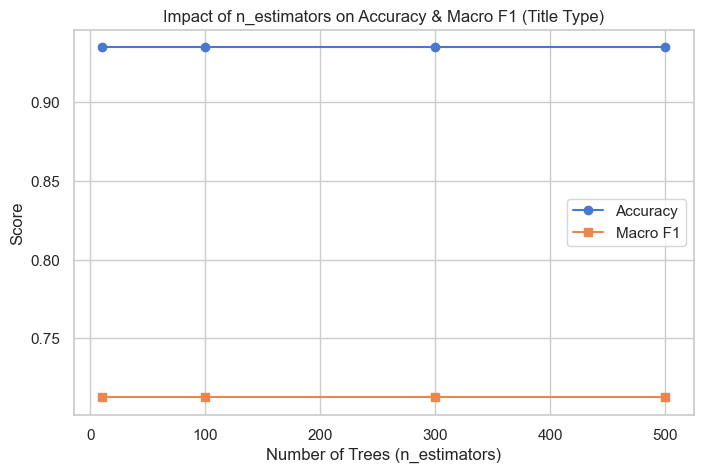

In [49]:
n_estimators_list = [10, 100, 300, 500]
accuracy_scores = []
f1_scores = []

for n in n_estimators_list:
    
    pipeline_n_estimators = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', RandomForestClassifier(random_state=42))
    ])
    # Accuracy
    acc = cross_val_score(pipeline_n_estimators, df_train, y_train_titleType, cv=5, scoring='accuracy').mean()
    accuracy_scores.append(acc)
    
    # Macro F1
    f1 = cross_val_score(pipeline_n_estimators, df_train, y_train_titleType, cv=5, scoring='f1_macro').mean()
    f1_scores.append(f1)

# Plot
plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, accuracy_scores, marker='o', label='Accuracy')
plt.plot(n_estimators_list, f1_scores, marker='s', label='Macro F1')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Score')
plt.title('Impact of n_estimators on Accuracy & Macro F1 (Title Type)')
plt.legend()
plt.show()


## Hyperparameter tuning

In [50]:
#COPIA PER OVERFITTING
random_search_100_tts = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_100,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_100_tts.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_100_tts = random_search_100_tts.best_index_
train_macro_f1_100_tts = random_search_100_tts.cv_results_['mean_train_f1_macro'][best_index_100_tts]

print(f"Validation macro F1: {random_search_100_tts.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_100_tts:.3f}")
print(f"Best parameters: {random_search_100_tts.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation macro F1: 0.763; vs macro F1 on train: 0.973
Best parameters: {'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}


In [51]:
cv_results_100_tts = pd.DataFrame(random_search_100_tts.cv_results_)
cv_results_100_tts['overfitting_gap'] = cv_results_100_tts['mean_train_f1_macro'] - cv_results_100_tts['mean_test_f1_macro']

cv_results_100_tts.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(20)

display(cv_results_100_tts[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.624346,0.580578,0.043768
1,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.562355,0.553323,0.009032
2,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.768988,0.691355,0.077633
3,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.554531,0.526812,0.027719
4,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.972893,0.763195,0.209698
...,...,...,...,...
95,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.625730,0.582817,0.042914
96,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.910115,0.692842,0.217273
97,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.732177,0.602660,0.129517
98,"{'clf__n_estimators': 100, 'clf__min_samples_s...",0.892587,0.746939,0.145649


In [52]:
random_search_300_tts = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_300,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_300_tts.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_300_tts = random_search_300_tts.best_index_
train_macro_f1_300_tts = random_search_300_tts.cv_results_['mean_train_f1_macro'][best_index_300_tts]

print(f"Validation macro F1: {random_search_300_tts.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_300_tts:.3f}")
print(f"Best parameters: {random_search_300_tts.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation macro F1: 0.767; vs macro F1 on train: 0.975
Best parameters: {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}


In [53]:
cv_results_300_tts = pd.DataFrame(random_search_300_tts.cv_results_)
cv_results_300_tts['overfitting_gap'] = cv_results_300_tts['mean_train_f1_macro'] - cv_results_300_tts['mean_test_f1_macro']

cv_results_300_tts.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(20)

display(cv_results_300_tts[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.629592,0.587660,0.041932
1,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.570777,0.562949,0.007827
2,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.774819,0.697353,0.077466
3,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.559649,0.530768,0.028881
4,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.974722,0.766826,0.207896
...,...,...,...,...
95,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.628660,0.586994,0.041667
96,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.910719,0.693165,0.217554
97,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.733306,0.607625,0.125681
98,"{'clf__n_estimators': 300, 'clf__min_samples_s...",0.896846,0.751055,0.145791


In [54]:
#COPIA PER OVERFITTING
random_search_500_tts = RandomizedSearchCV(
    pipeline_tts,
    param_distributions=param_list_500,
    n_iter=100,
    cv=3,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    verbose=2,
    random_state=0,
    n_jobs=-1,
    return_train_score=True
)

random_search_500_tts.fit(df_train, y_train_titleType)

print(f"BEST MODEL:")
best_index_500_tts = random_search_500_tts.best_index_
train_macro_f1_500_tts = random_search_500_tts.cv_results_['mean_train_f1_macro'][best_index_500_tts]

print(f"Validation macro F1: {random_search_500_tts.best_score_:.3f}; vs macro F1 on train: {train_macro_f1_500_tts:.3f}")
print(f"Best parameters: {random_search_500_tts.best_params_}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
BEST MODEL:
Validation macro F1: 0.767; vs macro F1 on train: 0.975
Best parameters: {'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}


In [55]:
cv_results_500_tts = pd.DataFrame(random_search_500_tts.cv_results_)
cv_results_500_tts['overfitting_gap'] = cv_results_500_tts['mean_train_f1_macro'] - cv_results_500_tts['mean_test_f1_macro']

cv_results_500_tts.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(20)

display(cv_results_500_tts[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']])

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
0,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.629477,0.585498,0.043979
1,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.567446,0.561041,0.006405
2,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.772872,0.697301,0.075571
3,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.555726,0.525722,0.030004
4,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.975038,0.766524,0.208514
...,...,...,...,...
95,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.627455,0.586821,0.040634
96,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.910390,0.694765,0.215625
97,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.730903,0.607171,0.123732
98,"{'clf__n_estimators': 500, 'clf__min_samples_s...",0.897230,0.749932,0.147297


In [56]:
#df_results_100 = pd.DataFrame(random_search_100.cv_results_)
df_results_300 = pd.DataFrame(random_search_300.cv_results_)
df_results_500 = pd.DataFrame(random_search_500.cv_results_)

#sort by macrof1
#df_results_100= df_results_100.sort_values(by="mean_test_f1_macro", ascending=False)
df_results_300 = df_results_300.sort_values(by="mean_test_f1_macro", ascending=False)
df_results_500 = df_results_500.sort_values(by="mean_test_f1_macro", ascending=False)

In [57]:
for name, df in {
    #"100": df_results_100,
    "300": df_results_300,
    "500": df_results_500,
}.items():
    row = df.iloc[0]
    print(
        f"Model {name}: "
        f"macro_f1={row['mean_test_f1_macro']:.6f} ± {row['std_test_f1_macro']:.6f}, "
        f"accuracy={row['mean_test_accuracy']:.6f} ± {row['std_test_accuracy']:.6f}"
    )

Model 300: macro_f1=0.308350 ± 0.002541, accuracy=0.443830 ± 0.002798
Model 500: macro_f1=0.307647 ± 0.001996, accuracy=0.445187 ± 0.002801


Again, we choose model 300, even though the gain in performance is very small.

They're all overfitted.

NB: for all models, the winning param combination is the same.

In [61]:
RF_tts = random_search_300_tts.best_estimator_
#joblib.dump(RF_tts, data_dir/"RF_tts.pkl")

In [62]:
y_pred_tts = RF_tts.predict(df_test)
print(classification_report(y_test_titleType, y_pred_tts, digits=3))

              precision    recall  f1-score   support

       movie      0.923     0.953     0.938     11045
       short      0.937     0.979     0.958      4930
   tvEpisode      0.987     0.990     0.988     21234
tvMiniSeries      0.742     0.680     0.710       491
     tvMovie      0.692     0.564     0.621      1861
    tvSeries      0.945     0.959     0.952      2820
     tvShort      0.750     0.170     0.278        88
   tvSpecial      0.629     0.709     0.667       327
       video      0.758     0.622     0.683      1535
   videoGame      0.972     0.977     0.974       526

    accuracy                          0.940     44857
   macro avg      0.834     0.760     0.777     44857
weighted avg      0.937     0.940     0.938     44857



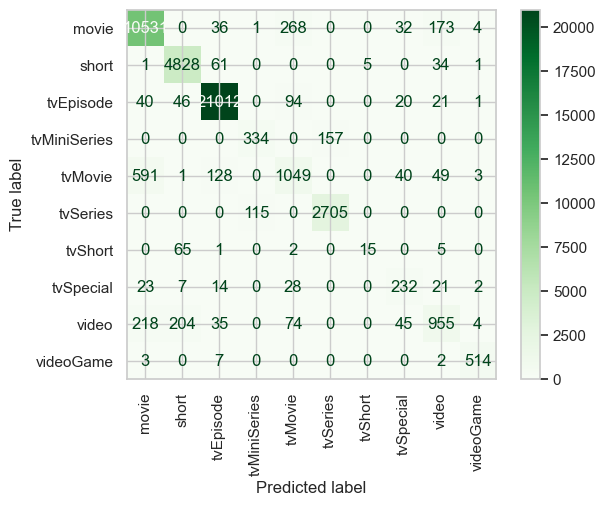

In [63]:
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred_tts, y_true=y_test_titleType,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

NB: prior random search with only class_weight = None, we got 0.728 → it's the most important param for this unbalanced task.


Best model thus far (comparison to SVM; macro f1: 0.746 vs 0.777, acc 0.938 vs 0.940).
As usual top classes have excellent performances (>0.9), to that we add videogame and tvSeries. tvSeries and tvminiSeries only get confused among each other.
Very good performances for all classes, except tvShort: all have F1 > 0.62

has managed to generalize on tvMovie and tvMiniSeries: although there is still confusion w/ the more popular movie and tvSeries, they are correctly classified most of the time.

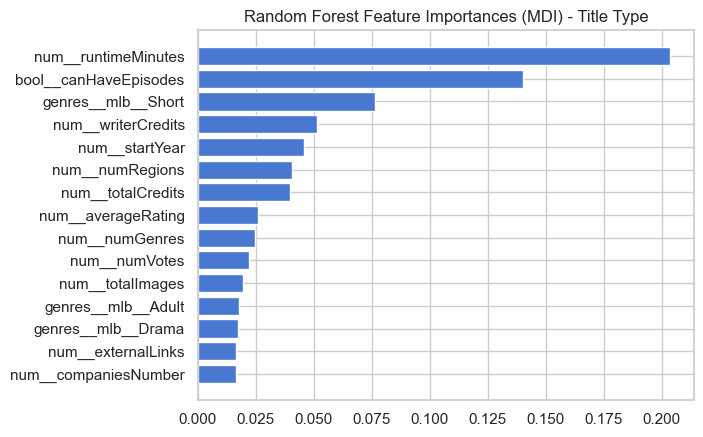

In [64]:
nbr_features = 15

RF_tts_clf = RF_tts.named_steps['clf']
RF_tts_preprocessor = RF_tts.named_steps['preprocessor']
feature_names = RF_tts_preprocessor.get_feature_names_out()
tree_feature_importances = RF_tts_clf.feature_importances_

sorted_idx = tree_feature_importances.argsort()[-nbr_features:]

y_ticks = np.arange(0, len(sorted_idx))
fig, ax = plt.subplots()
plt.barh(y_ticks, tree_feature_importances[sorted_idx])
plt.yticks(y_ticks, feature_names[sorted_idx])
plt.title("Random Forest Feature Importances (MDI) - Title Type")
plt.show()

Interestingly, the top two features for both Logistic Regression and LinearSVC (canHaveEpisodes and genre Short) have been overtaken by runtimeMinutes. Cf. data understanding: there's a relationship between title types and runtime

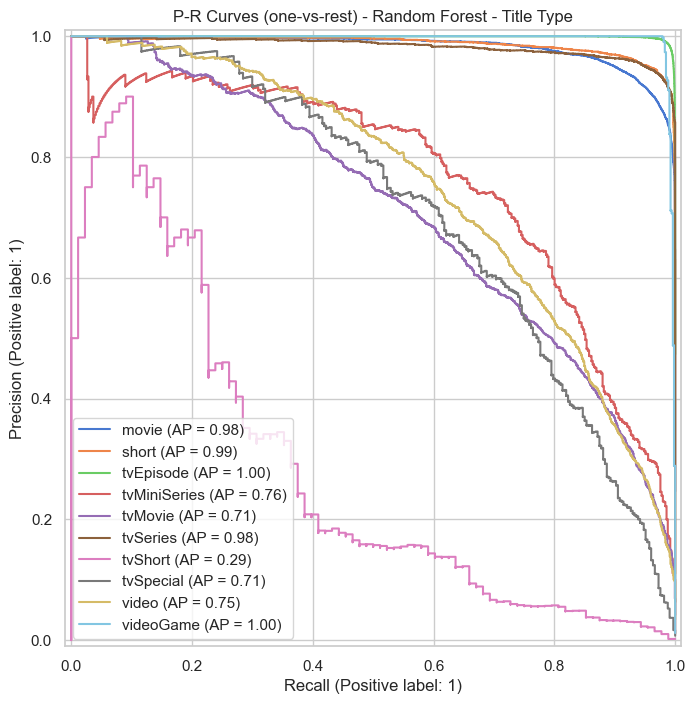

Macro average PR AUC: 0.818


In [65]:
# Get the classes and predictions from your trained model
class_labels = RF_tts.classes_
y_score = RF_tts.predict_proba(df_test)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("P-R Curves (one-vs-rest) - Random Forest - Title Type")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")

the PR AUC is significantly better than all other models', with a good balance between Precision and Recall for all classes (except tvShort).

# Trying to mitigate overfitting

Let's check our cv results to find combinations with decent trade off between validation and test macro f1.

## Rating
What we had: 

Validation macro F1: 0.308; vs macro F1 on train: 0.968

In [70]:
pd.set_option("display.max_colwidth", None)

In [77]:
cv_results_100.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(50)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
74,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.964319,0.307712,0.656607
57,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.964285,0.307461,0.656824
60,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.931032,0.303607,0.627424
4,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.880435,0.300204,0.580230
68,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.989795,0.296438,0.693358
94,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': None}",0.995053,0.295759,0.699294
92,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.852278,0.294658,0.557620
28,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.836121,0.292615,0.543506
39,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.992070,0.288597,0.703473
26,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': None}",0.969376,0.279767,0.689608


In [76]:
cv_results_300.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(50)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
57,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.967659,0.308350,0.659309
74,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.966457,0.306802,0.659655
60,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.935966,0.305065,0.630901
4,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.888778,0.301988,0.586790
92,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.859662,0.297841,0.561822
94,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': None}",0.995178,0.296445,0.698733
28,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.844373,0.295812,0.548562
68,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.990290,0.295513,0.694777
39,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.992070,0.289885,0.702185
26,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': None}",0.970788,0.282247,0.688540


In [75]:
cv_results_500.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(50)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
57,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.968378,0.307647,0.660731
74,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.966610,0.306937,0.659673
60,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.936529,0.306539,0.629990
4,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.889757,0.301593,0.588164
28,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.848222,0.298464,0.549758
92,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.862308,0.298182,0.564126
68,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.990395,0.295665,0.694729
94,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': None}",0.995175,0.294565,0.700610
39,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.992060,0.290577,0.701483
26,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': None}",0.971078,0.282425,0.688652


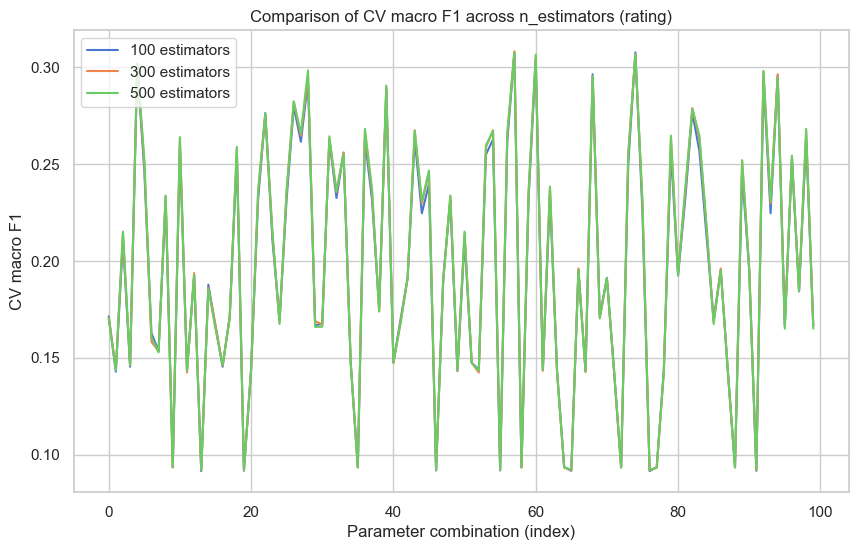

In [101]:
plt.figure(figsize=(10,6))

plt.plot(cv_results_100.index, cv_results_100["mean_test_f1_macro"], label="100 estimators")
plt.plot(cv_results_300.index, cv_results_300["mean_test_f1_macro"], label="300 estimators")
plt.plot(cv_results_500.index, cv_results_500["mean_test_f1_macro"], label="500 estimators")

plt.xlabel("Parameter combination (index)")
plt.ylabel("CV macro F1")
plt.title("Comparison of CV macro F1 across n_estimators (rating)")
plt.legend()
plt.show()

For the different parameter combinations, the n. of estimators is not a strong driver of performance.

All competitive models are overfitted. We try the best performing model with an overfitting gap ( train - validation macro f1) smaller than 0.30.
We choose:
62	{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 10, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}	0.485944	0.238049	0.247895

In [91]:
pipeline = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [92]:
#Remember to re-prepare your data do that df_train and df_test are correct

params_62 = cv_results_300.loc[62, 'params']
print(params_62)

pipeline.set_params(**params_62)

pipeline.fit(df_train, y_train_rating)

{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 10, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
y_pred = pipeline.predict(df_test)
print(classification_report(y_test_rating, y_pred, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.065     0.500     0.115        22
      (1, 2]      0.068     0.248     0.106       133
      (2, 3]      0.092     0.163     0.118       374
      (3, 4]      0.146     0.296     0.196      1035
      (4, 5]      0.223     0.366     0.277      2750
      (5, 6]      0.321     0.326     0.323      6270
      (6, 7]      0.457     0.218     0.295     11750
      (7, 8]      0.558     0.424     0.482     14613
      (8, 9]      0.321     0.370     0.344      6591
     (9, 10]      0.134     0.635     0.221      1319

    accuracy                          0.345     44857
   macro avg      0.238     0.355     0.248     44857
weighted avg      0.416     0.345     0.359     44857



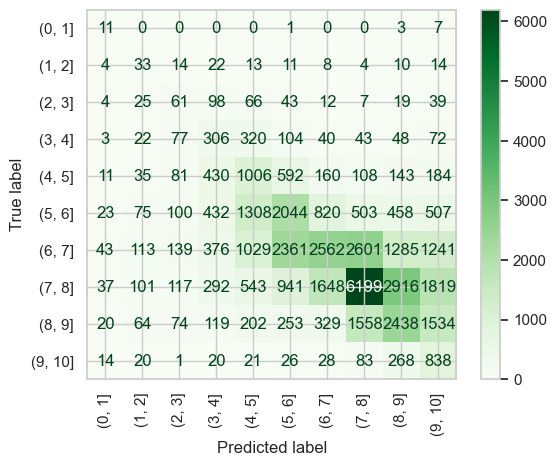

In [94]:
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred, y_true=y_test_rating,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Test macro f1: 0.248 vs 0.325 → the overfitted model is better.

## TitleType
Same thing.

In [102]:
cv_results_100_tts.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(50)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
4,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.972893,0.763195,0.209698
28,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.955471,0.761511,0.193960
92,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.963050,0.759325,0.203725
57,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.994776,0.755036,0.239741
60,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.980126,0.753168,0.226958
74,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.995572,0.752604,0.242969
36,"{'clf__n_estimators': 100, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 5, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.892587,0.746939,0.145649
98,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.892587,0.746939,0.145649
27,"{'clf__n_estimators': 100, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 5, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.889863,0.745800,0.144063
56,"{'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.889863,0.745800,0.144063


In [103]:
cv_results_300_tts.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(50)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
4,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.974722,0.766826,0.207896
92,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.964898,0.763499,0.201399
28,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.956770,0.763005,0.193765
60,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.981455,0.756996,0.224458
57,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.994909,0.754796,0.240113
74,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.996243,0.752047,0.244196
36,"{'clf__n_estimators': 300, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 5, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.896846,0.751055,0.145791
98,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.896846,0.751055,0.145791
27,"{'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 5, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.893031,0.749452,0.143579
56,"{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.893031,0.749452,0.143579


In [104]:
cv_results_500_tts.sort_values(
    by=["mean_test_f1_macro", "overfitting_gap"], 
    ascending=[False, True]
).head(50)[['params','mean_train_f1_macro', 'mean_test_f1_macro', 'overfitting_gap']]

,params,mean_train_f1_macro,mean_test_f1_macro,overfitting_gap
4,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.975038,0.766524,0.208514
92,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.965538,0.763446,0.202092
28,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.957581,0.762208,0.195372
60,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.982107,0.758912,0.223195
57,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.995001,0.755318,0.239683
74,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_depth': None, 'clf__criterion': 'entropy', 'clf__class_weight': 'balanced'}",0.996457,0.751990,0.244468
79,"{'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 5, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.889715,0.750483,0.139232
83,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_depth': 25, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.889715,0.750483,0.139232
36,"{'clf__n_estimators': 500, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 5, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.897230,0.749932,0.147297
98,"{'clf__n_estimators': 500, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 5, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}",0.897230,0.749932,0.147297


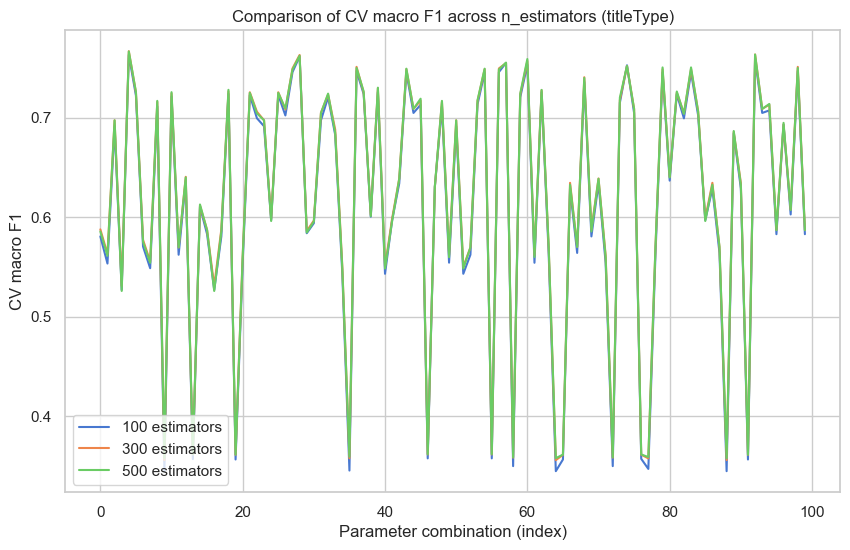

In [105]:
plt.figure(figsize=(10,6))

plt.plot(cv_results_100_tts.index, cv_results_100_tts["mean_test_f1_macro"], label="100 estimators")
plt.plot(cv_results_300_tts.index, cv_results_300_tts["mean_test_f1_macro"], label="300 estimators")
plt.plot(cv_results_500_tts.index, cv_results_500_tts["mean_test_f1_macro"], label="500 estimators")

plt.xlabel("Parameter combination (index)")
plt.ylabel("CV macro F1")
plt.title("Comparison of CV macro F1 across n_estimators (titleType)")
plt.legend()
plt.show()

For the different parameter combinations, the n. of estimators is not a strong driver of performance.

In this case, the overfitting is less pronounced. We try the best performing model with an overfitting gap ( train - validation macro f1) smaller than 0.1.

62	{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 10, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}	0.826775	0.727521	0.099255

In [107]:
pipeline = Pipeline(steps=[
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [108]:
#Remember to re-prepare your data do that df_train and df_test are correct

params_62 = cv_results_300_tts.loc[62, 'params']
print(params_62)

pipeline.set_params(**params_62)

pipeline.fit(df_train, y_train_titleType)

{'clf__n_estimators': 300, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 10, 'clf__max_depth': None, 'clf__criterion': 'gini', 'clf__class_weight': 'balanced'}


,steps,"[('preprocessor', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bool', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [109]:
y_pred = pipeline.predict(df_test)
print(classification_report(y_test_titleType, y_pred, digits=3))

              precision    recall  f1-score   support

       movie      0.950     0.880     0.914     11045
       short      0.935     0.963     0.949      4930
   tvEpisode      0.990     0.977     0.983     21234
tvMiniSeries      0.579     0.786     0.667       491
     tvMovie      0.519     0.679     0.588      1861
    tvSeries      0.960     0.901     0.929      2820
     tvShort      0.265     0.295     0.280        88
   tvSpecial      0.345     0.807     0.484       327
       video      0.647     0.591     0.618      1535
   videoGame      0.878     0.983     0.927       526

    accuracy                          0.916     44857
   macro avg      0.707     0.786     0.734     44857
weighted avg      0.929     0.916     0.921     44857



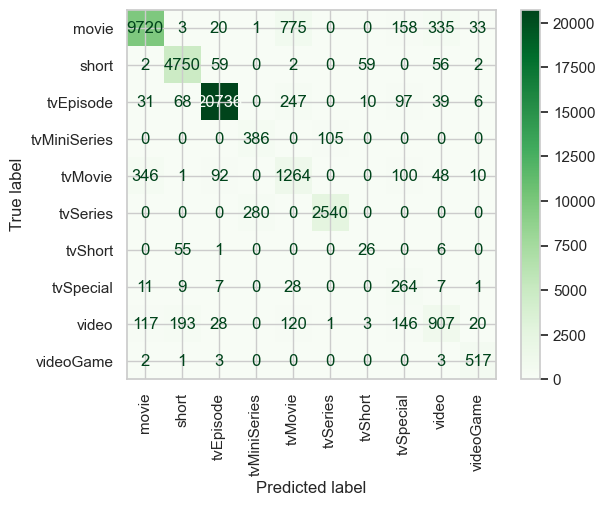

In [110]:
ConfusionMatrixDisplay.from_predictions(y_pred= y_pred, y_true=y_test_titleType,                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Test macro f1: 0.734 vs 0.777 → the overfitted model is better.

# Plotting overfitting gaps

NameError: name 'plt' is not defined